# Diffuse Emission

In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./

CIAO configuration is complete... 
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3


## Download Data and repro

In [2]:
/bin/rm -rf 315 
download_chandra_obsid 315


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  readme   ascii      10 Kb  ####################          < 1 s  189.8 kb/s
  oif      fits       25 Kb  ####################          < 1 s  1436.3 kb/s
  vv       pdf        43 Kb  ####################          < 1 s  2787.5 kb/s
  cntr_img fits      258 Kb  ####################          < 1 s  3732.0 kb/s
  cntr_img jpg       656 Kb  ####################          < 1 s  16221.2 kb/s
  evt2     fits       23 Mb  ####################          < 1 s  27719.3 kb/s
  full_img fits       79 Kb  ####################          < 1 s  2636.9 kb/s
  full_img jpg        48 Kb  ####################          < 1 s  4830.6 kb/s
  src2     fits       22 Kb  ####################          < 1 s  473.0 kb/s
  src_img  jpg        49 Kb  ####################          < 1 s  653.4 kb/s
  bpix     fits       10 Kb  ####################          < 1 s

In [3]:
/bin/rm -rf repro 
chandra_repro 315 ./repro


Processing input directory '/data/sdsreg/thread_output/CIAO4.9/diffuse_emission/315'

Resetting afterglow status bits in evt1.fits file...

Running the destreak tool on the evt1.fits file...

Running acis_build_badpix and acis_find_afterglow to create a new bad pixel file...

Running acis_process_events to reprocess the evt1.fits file...
Output from acis_process_events:
# acis_process_events (CIAO 4.9): WARNING: problem reading ctifile, cti adjustment will not be applied. Changing apply_cti=yes to apply_cti=no.
Filtering the evt1.fits file by grade and status and time...
Applying the good time intervals from the flt1.fits file...
The new evt2.fits file is: /data/sdsreg/thread_output/CIAO4.9/diffuse_emission/repro/acisf00315_repro_evt2.fits

Updating the event file header with chandra_repro HISTORY record
Creating FOV file...
Setting observation-specific bad pixel file in local ardlib.par.

Cleaning up intermediate files

         /data/sdsreg/thread_output/CIAO4.9/diffuse_emission/rep

In [4]:
# Work around crates bug!
dmcopy "repro/acisf00315_repro_evt2.fits[ccd_id=7]" repro/c7.evt cl+

fluximage "repro/c7.evt" images/ binsize=1 bands=broad clob+

Running fluximage
Version: 12 September 2016

Using CSC ACIS broad science energy band.
Aspect solution repro/pcadf060414371N003_asol1.fits found.
Bad-pixel file repro/acisf00315_repro_bpix1.fits found.
Mask file repro/acisf00315_000N003_msk1.fits found.

The output images will have 1289 by 1289 pixels, pixel size of 0.492 arcsec,
    and cover x=3536.5:4825.5:1,y=3171.5:4460.5:1.

Running tasks in parallel with 4 processors.
Creating aspect histogram for obsid 315
Creating instrument map for obsid 315
Creating exposure map for obsid 315
Thresholding data for obsid 315
Exposure-correcting image for obsid 315

The following files were created:

 The clipped counts image is:
     images/broad_thresh.img

 The clipped exposure map is:
     images/broad_thresh.expmap

 The exposure-corrected image is:
     images/broad_flux.img



## Identify and Remove Point Source

### Create an Image of the Region

In [5]:
dmcopy "repro/acisf00315_repro_evt2.fits[energy=300:7000][bin x=4004.5:4404.5:1,y=3625.5:4025.5:1]" \
       original.fits cl+

In [6]:
get_sky_limits images/broad_thresh.img 

Running: get_sky_limits
  version: 07 October 2016
Checking binning of image: images/broad_thresh.img
  Image has 1289 x 1289 pixels
  Pixel size is 1.0 by 1.0
  Lower left (0.5,0.5) corner is x,y= 3536.5, 3171.5
  Upper right (1289.5,1289.5) corner is x,y= 4825.5, 4460.5
  DM filter is:
    x=3536.5:4825.5:#1289,y=3171.5:4460.5:#1289
  mkexpmap xygrid value is:
    3536.5:4825.5:#1289,3171.5:4460.5:#1289


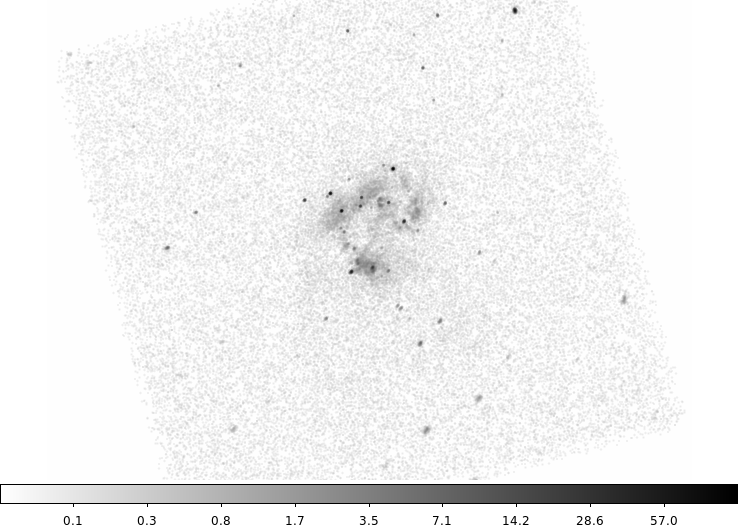

In [7]:
ds9 images/broad_thresh.img -scale log -zoom 0.5 -smooth -invert -saveimage png ds9_01.png -quit
display < ds9_01.png

### Source detection with wavdetect

In [8]:
mkpsfmap images/broad_thresh.img images/broad_1.4967.psfmap \
  energy=1.4967 ecf=0.393 cl+

In [9]:
dmstat images/broad_1.4967.psfmap cen-

broad_1.4967.psfmap[arcsec]
    min:	0.22391065955 	      @:	( 4088 4126 )
    max:	4.8685688972 	      @:	( 4825 3172 )
   mean:	1.4646802446 
  sigma:	0.96807968887 
    sum:	2433596.9847 
   good:	1661521 
   null:	0 


-----------------------------------------
Welcome to ChIPS: CXC's Plotting Package
-----------------------------------------
CIAO 4.9 ChIPS version 1 Friday, December 2, 2016



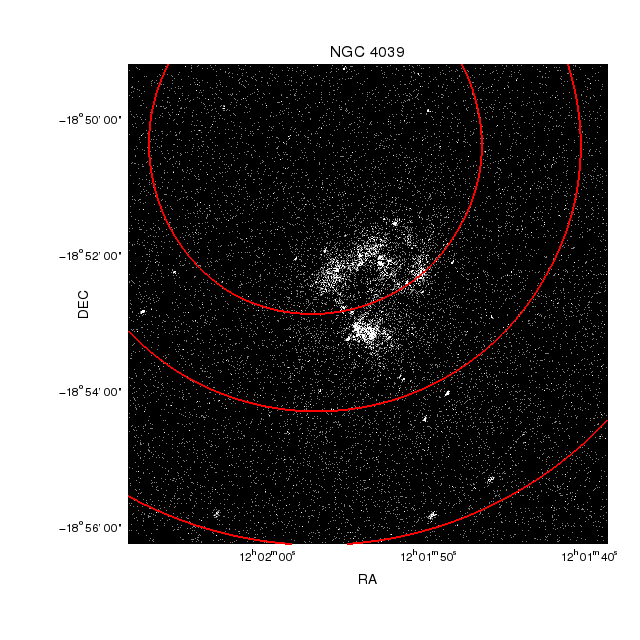

In [10]:
cat << EOM > chps.cmd
make_figure("images/broad_thresh.img", "image")
set_image(["threshold", [0,2], "depth", 50])
add_contour("images/broad_1.4967.psfmap")
set_contour(["levels", [0.5, 1, 2]])
set_contour(["color", "red", "thickness", 2])
zoom(1.5)
set_xaxis(["tickformat", "%ra"])
set_yaxis(["tickformat", "%dec"])
reposition_plot(0.2, 0.15, 0.95, 0.9)
print_window("chips_1.png","export.clobber=True")
quit()
EOM

chips chps.cmd
display < chips_1.png

In [11]:
pset wavdetect psffile=images/broad_1.4967.psfmap
pset wavdetect regfile=sources.reg 
pset wavdetect ellsigma=4
wavdetect images/broad_thresh.img \
  sources.fits sources.scell sources.image sources.nbkg clobber=yes mode=h


Modify, delete non-obvious sources.

__THIS MAY NEED TO BE MODIFIED PER RELEASE IN THE FUTURE__

In [12]:
dmcopy sources.fits"[exclude component=11,19,21,23,25,32,33,36,38,40,43,69,70,71,72]" sources_mod.fits cl+


In [13]:
 dmmakereg region="region(sources_mod.fits)" out=source_mod.reg clob+ ker=ascii
 head sources_mod.reg

# Region file format: CIAO version 1.0
ellipse(4390.2083,3333.5938,10.644843,7.650496,44.476522)
ellipse(4295.1966,3436.9775,10.434737,7.513638,54.739983)
ellipse(4400.35,3500.95,8.966743,6.815609,42.261833)
ellipse(4283.0112,3610.3631,5.756376,3.547797,60.739769)
ellipse(4320.7324,3652.8873,5.119402,3.936716,18.870479)
ellipse(4323.1667,3656.8889,2.343015,2.036951,47.973432)
ellipse(4094.1974,3659.8421,5.086866,3.294155,43.659596)
ellipse(4260.7727,3658.7727,8.551467,4.094002,45.831784)
ellipse(4244,3680.3889,5.023601,2.137519,44.730471)


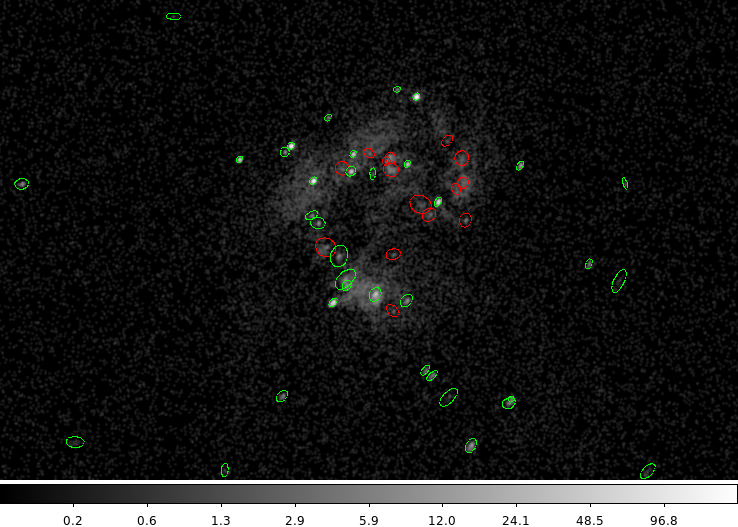

In [14]:
ds9 images/broad_thresh.img  -region sources_mod.fits -region color red -region sources.fits  -smooth radius 2 -smooth -scale log -saveimage png ds9_02.png -quit
display < ds9_02.png

In [15]:
dmmakereg region="region(sources_mod.fits)" out=sources_mod.fits clob+ ker=fits
dmlist sources_mod.fits cols

 
--------------------------------------------------------------------------------
Columns for Table Block REGION
--------------------------------------------------------------------------------
 
ColNo  Name                 Unit        Type             Range
   1   POS(X,Y)             pixel        Real8          -Inf:+Inf            Position
   2   SHAPE                             String[16]                          Region shape type
   3   R[2]                 pixel        Real8(2)       -Inf:+Inf            Radius
   4   ROTANG[2]            deg          Real8(2)       -Inf:+Inf            Angle
   5   COMPONENT                         Int2           -                    Component number


### Create src and bkg regions

In [16]:
mkdir -p sources
/bin/rm -f sources/*
pset roi infile=sources_mod.fits
pset roi outsrcfile=sources/src%d.fits
pset roi bkgfactor=0.5
roi mode=h clob+


In [17]:
pget roi num_srcs

57


In [18]:
dmlist sources_mod.fits counts

60      


In [19]:
ls -1 sources/ | head -5

src1.fits
src10.fits
src11.fits
src12.fits
src13.fits


In [20]:
dmlist sources/src1.fits blocks

 
--------------------------------------------------------------------------------
Dataset: sources/src1.fits
--------------------------------------------------------------------------------
 
     Block Name                          Type         Dimensions
--------------------------------------------------------------------------------
Block    1: PRIMARY                        Null        
Block    2: SRCREG                         Table         5 cols x 1        rows
Block    3: BKGREG                         Table         5 cols x 2        rows


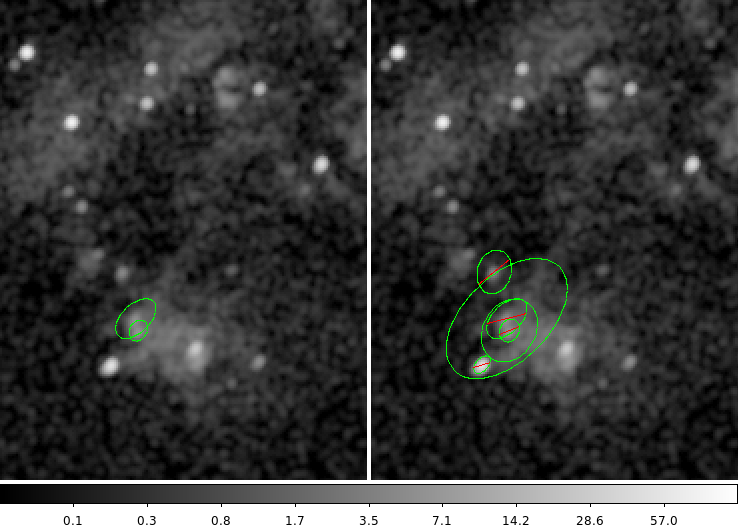

In [21]:
ds9 -zoom 2 -smooth -scale log images/broad_thresh.img -region sources/src14.fits \
     images/broad_thresh.img -region "sources/src14.fits[bkgreg]" \
     -saveimage png ds9_03.png -quit 
     
display < ds9_03.png

In [22]:
splitroi "sources/src*.fits" exclude

In [23]:
dmmakereg region="region(exclude.bg.reg)" out=exclude.bg.fits cl+ ker=fits

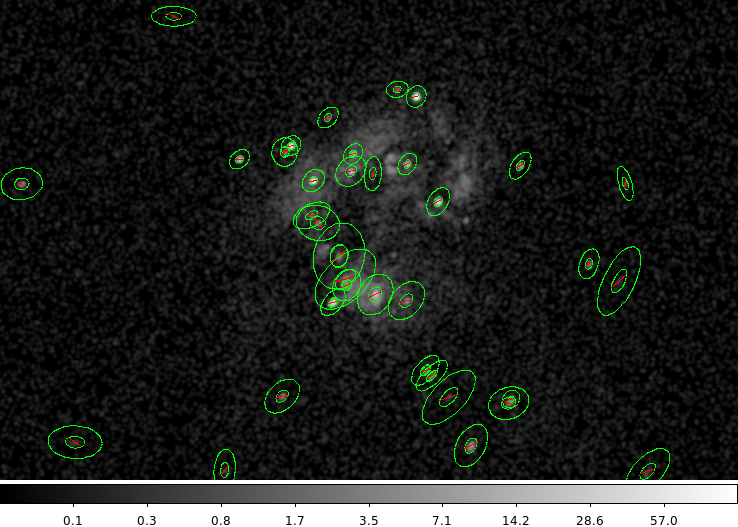

In [24]:
ds9 images/broad_thresh.img -scale log -smooth -region exclude.bg.fits \
  -saveimage png ds9_04.png -quit

display < ds9_04.png

#### Alt using stacks

In [25]:
ls -1 sources/src*fits | sed 's/.*/region(&)/' > src.reg
head -5 src.reg

region(sources/src1.fits)
region(sources/src10.fits)
region(sources/src11.fits)
region(sources/src12.fits)
region(sources/src13.fits)


In [26]:
ls -1 sources/src*fits | sed 's/.*/region(&[bkgreg])/' > bg.reg
head -5 bg.reg

region(sources/src1.fits[bkgreg])
region(sources/src10.fits[bkgreg])
region(sources/src11.fits[bkgreg])
region(sources/src12.fits[bkgreg])
region(sources/src13.fits[bkgreg])


### Dmfilth it

In [27]:
pset dmfilth infile=images/broad_thresh.img
pset dmfilth outfile=diffuse.img
pset dmfilth method=POISSON
pset dmfilth srclist=@exclude.src.reg
pset dmfilth bkglist=@exclude.bg.reg
pset dmfilth randseed=0
dmfilth mode=h cl+ 

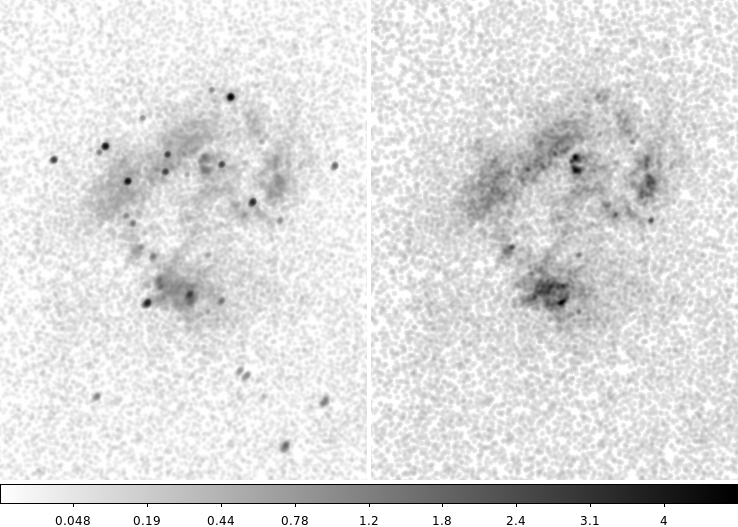

In [28]:
ds9 images/broad_thresh.img -invert -smooth -log  diffuse.img -smooth -scale sqrt -invert -saveimage png ds9_05.png -quit

display < ds9_05.png

## Smooth


In [29]:
pset aconvolve infile=diffuse.img
pset aconvolve outfile=diffuse.sm.img
pset aconvolve kernelspec="lib:gaus(2,5,1,7,7)"
pset aconvolve method=fft
aconvolve mode=h clob+


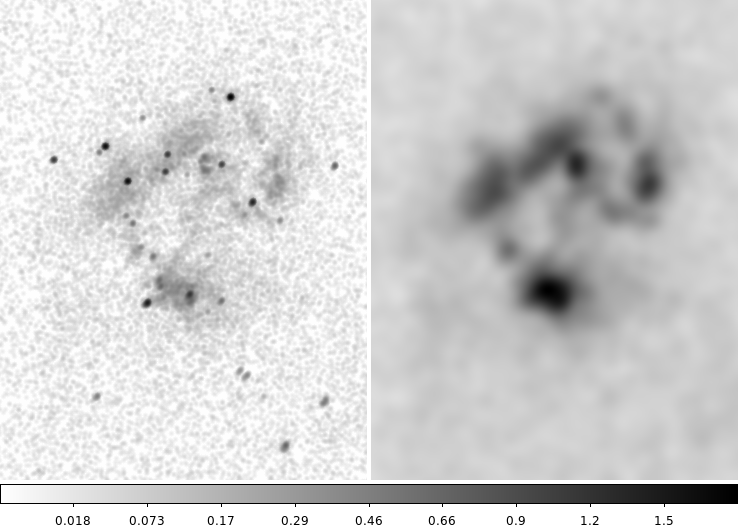

In [30]:
ds9 images/broad_thresh.img -invert -smooth -log  \
    diffuse.sm.img -smooth -scale sqrt -invert \
    -saveimage png ds9_06.png -quit

display < ds9_06.png

## Exposure Correct

In [31]:
dmimgcalc diffuse.img images/broad_thresh.expmap diffuse_exp.img div cl+

In [32]:
aconvolve diffuse_exp.img diffuse_exp.sm.img "lib:gauss(2,5,1,7,7)" method=fft cl+

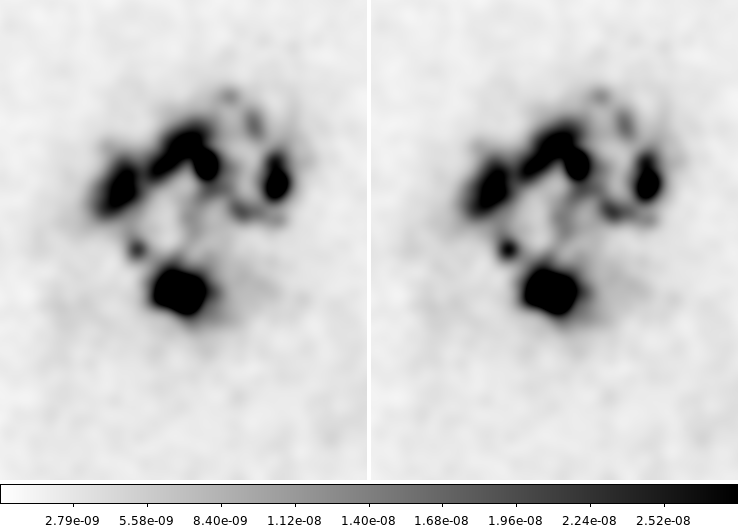

In [33]:
ds9  diffuse.sm.img -invert -scale mode 99.5 \
     diffuse_exp.sm.img -invert -scale mode 99.5 \
     -saveimage png ds9_07.png -quit

display < ds9_07.png